# Marker Repo - annotation human heart atlas

The following example shows how data from the Human Heart Atlas can be used to generate marker lists using the already annotated clusters, and to annotate the already annotated data using PanglaoDB.

## Loading packages

In [1]:
import markerrepo.marker_repo as mr
import markerrepo.wrappers as wrap
import markerrepo.annotation as annot
import scanpy as sc

%load_ext autoreload
%autoreload 2

## Settings

Specify path of the cloned repository and the h5ad file which is going to be annotated.

In [2]:
repo_path = "/mnt/workspace/mkessle/projects/annotate_by_marker_and_features"
h5ad_path = "/mnt/workspace/mkessle/master/refdata/Global_lognormalised.h5ad"

Load anndata

In [3]:
adata = sc.read_h5ad(h5ad_path)

List all possible settings.

In [4]:
annot.list_possible_settings(repo_path, adata)

Possible Settings:
----------------------------------------
1. Possible Organisms or Taxon IDs:
  - human 9606
  - mouse 10090
  - zebrafish 7955
  - rat 10114
  - pig 9823
  - medaka 8090
  - chicken 9031
  - drosophila 7215
  - yeast 4932

2. Available Columns in adata.obs:
  - sangerID
  - donor
  - donor_type
  - region
  - age
  - gender
  - facility
  - cell_or_nuclei
  - modality
  - kit_10x
  - flushed
  - cell_type
  - cell_state
  - n_genes
  - n_genes_by_counts
  - total_counts
  - total_counts_mt
  - pct_counts_mt
  - total_counts_ribo
  - pct_counts_ribo
  - scrublet_score

3. Available Columns in adata.var:
  - gene_name_scRNA-0-original
  - gene_name_snRNA-1-original
  - gene_name_multiome-2-original
  - gene_id

4. Available Columns to Search in Marker Repository:
  - List name
  - Marker type
  - Organism name
  - Taxonomy ID
  - Submitter name
  - List type
  - Source
  - tags_transferred
  - Tissue
  - Date
  - Email
  - Marker
  - Info
------------------------------

In [5]:
# taxonomy ID or organism name e.g. "human" or 9606
organism = "human" 
# the column of the .obs table where the ranked genes groups are stored e.g. "rank_genes_groups"
# if no ranking has been performed yet, enter None
rank_genes_column = None
# the column of the .var table where the gene symbols or ensembl IDs or stored
# enter None if the index column of the .var table are already gene symbols or ensembl IDs 
# which you want to use for your annotation
genes_column = "gene_id"
# the .obs table column of the clustering you want to annotate e.g. "leiden" or "louvain"
column = "cell_type"
# specify wether your index of the .var tables are ensembl IDs (True) or gene symbols (False)
ensembl = True
# specify the marker lists selection you want to use for the annotation
# the column to search in, None to search all columns, e.g. "source", "Organism name", etc.
col_to_search = "Source"
# search terms: "-" exclude keyword, "+" must contain keyword
# separate keywords with  "," e.g. ["+panglao.se", "+mouse"]
search_terms = ["panglao.se"]

Validate input and load anndata object

In [6]:
annot.validate_settings(repo_path, adata, organism, rank_genes_column, genes_column, column, ensembl, col_to_search, search_terms)

Initiating whitelist fetching...
Directory /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/metadata_whitelists already exists.
Updating the existing repository...
Repository updated.
Whitelist fetching process completed.

All settings are valid.
Summary of settings:
----------------------------------------
  Repo path: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features
  Organism: human
  Rank genes column: None
  Genes column: gene_id
  Clustering column: cell_type
  Ensembl IDs: True
  Column to search: Source
  Search terms: ['panglao.se']
----------------------------------------


True

## Prepare adata

### Set genes to index, if not already done.

In [7]:
if genes_column:
    adata.var.reset_index(inplace=True)  # remove old index values and save them in the column ['index']
    adata.var.set_index(genes_column, inplace=True)  # set genes as index
    adata.var.index = adata.var.index.astype('str')  # to avoid index being categorical
    adata.var_names_make_unique(join='_')
    
display(adata.var)

,gene_name-new,gene_name_scRNA-0-original,gene_name_snRNA-1-original,gene_name_multiome-2-original
gene_id,,,,
ENSG00000243485,MIR1302-2HG,MIR1302-2HG,MIR1302-2HG,MIR1302-2HG
ENSG00000237613,FAM138A,FAM138A,FAM138A,FAM138A
ENSG00000186092,OR4F5,OR4F5,OR4F5,OR4F5
ENSG00000238009,AL627309.1,AL627309.1,AL627309.1,AL627309.1
ENSG00000239945,AL627309.3,AL627309.3,AL627309.3,AL627309.3
...,...,...,...,...
ENSG00000277856,AC233755.2,AC233755.2,AC233755.2,AC233755.2
ENSG00000275063,AC233755.1,AC233755.1,AC233755.1,AC233755.1
ENSG00000271254,AC240274.1,AC240274.1,AC240274.1,AC240274.1


## Prepare annotation

### Ranking

Rank genes, if not already done.

In [8]:
if not rank_genes_column:
    adata.uns['log1p']['base'] = None
    rank_genes_column = f'rank_genes_groups_{column}'
    print(f'Ranking genes groups for clusters using obs column {column}')
    sc.tl.rank_genes_groups(adata, groupby=f'{column}', use_raw=False, key_added=rank_genes_column)

Ranking genes groups for clusters using obs column cell_type


         Falling back to preprocessing with `sc.pp.pca` and default params.


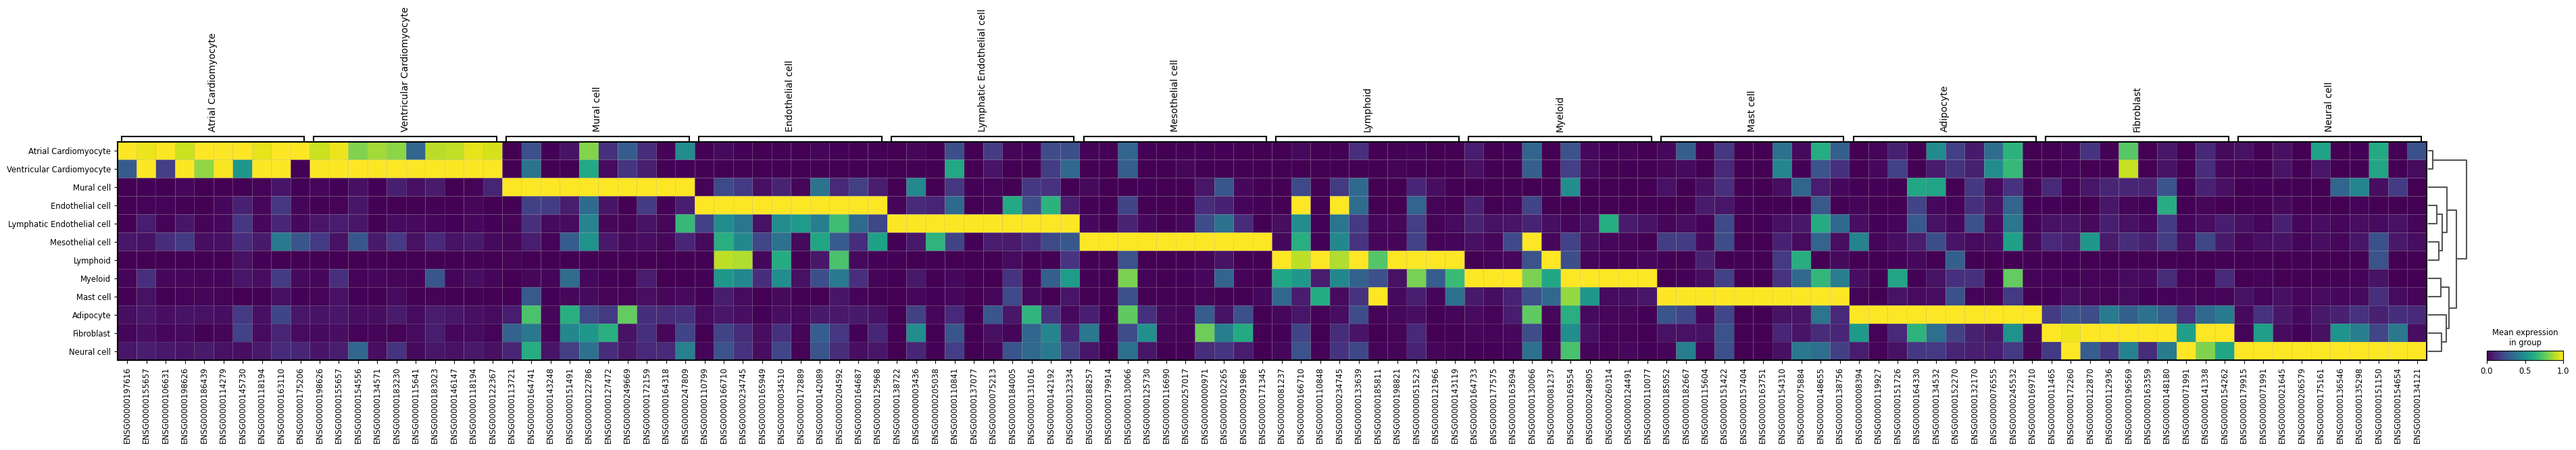

In [9]:
sc.pl.rank_genes_groups_matrixplot(adata, standard_scale='var', n_genes=10, key=rank_genes_column, show=True)

## Create suitable marker list(s)

The paths of the marker lists will be stored in the <b>marker_lists</b> variable. They will work as input for the actual cell type annotation of the next cell. If the index of adata.var contains ensembl IDs, set <b>ensembl=True</b>, otherwise gene symbols are used.

In [10]:
organism = mr.update_organism(organism, repo_path)
marker_lists = wrap.create_marker_lists(organism, repo_path=repo_path, 
                                        style="score", file_name="human_heart_atlas", ensembl=ensembl,
                                        col_to_search=col_to_search, search_terms=search_terms, force_homology=False)

Found 86 marker lists for the given organism human.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Tissue,Date,Email,Marker,Info
ID,,,,,,,,,,,,,
1688745545837,HCM_human_fetus,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,fetus,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[PECAM1, ENSG00000261371, CD163, ENSG000001775...","[Natural killer cell, Immune cell, T cell, Mye..."
168874554211252,Panglao_human_skin,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,skin,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[DSG2, ENSG00000046604, HLA-DRB9, ENSG00000196...","[Melanocytes, Trichocytes, Merkel cells, Seboc..."
168874554264756,Panglao_human_lungs,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,lung,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CEACAM1, ENSG00000079385, MUC20, ENSG00000176...","[Clara cells, Ionocytes, Ciliated cells, Pulmo..."
168874554292179,Panglao_human_na,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,na,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[HLF, ENSG00000108924, ABCC8, ENSG00000006071,...","[Glomus cells, T cells naive, Pluripotent stem..."
168874554338416,HCM_human_adipose-tissue,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,adipose tissue,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[TNFRSF9, ENSG00000049249, KRT19, ENSG00000171...","[Immature endothelial cell, M2 macrophage, Mes..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688745545683176,HCM_human_esophageal,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,esophagus,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[SOX2, ENSG00000181449]",[Esophageal squamous cell]
1688745545764487,HCM_human_gingiva,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,gingiva,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CD44, ENSG00000026508, NT5E, ENSG00000135318,...",[Mesenchymal stem cell]
1688745545897512,HCM_human_head-and-neck,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,head-and-neck,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CD44, ENSG00000026508, CD3D, ENSG00000167286,...","[Cancer stem cell, Conventional CD4 T cell, Me..."


Found 30 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Tissue,Date,Email,Marker,Info
ID,,,,,,,,,,,,,
168874554211252,Panglao_human_skin,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,skin,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[DSG2, ENSG00000046604, HLA-DRB9, ENSG00000196...","[Melanocytes, Trichocytes, Merkel cells, Seboc..."
168874554264756,Panglao_human_lungs,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,lung,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CEACAM1, ENSG00000079385, MUC20, ENSG00000176...","[Clara cells, Ionocytes, Ciliated cells, Pulmo..."
168874554292179,Panglao_human_na,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,na,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[HLF, ENSG00000108924, ABCC8, ENSG00000006071,...","[Glomus cells, T cells naive, Pluripotent stem..."
1688745542115122,Panglao_human_thymus,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,thymus,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[UCP2, ENSG00000175567, CD8A, ENSG00000153563,...",[Thymocytes]
1688745542118741,Panglao_human_urinary-bladder,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,bladder,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[UMODL1, ENSG00000177398, UPK2, ENSG0000011037...",[Urothelial cells]
1688745542119139,Panglao_human_smooth-muscle,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,smooth muscle,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[ITGA8, ENSG00000077943, CDH11, ENSG0000014093...","[Airway smooth muscle cells, Myoepithelial cel..."
1688745542129286,Panglao_human_gi-tract,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,gi-tract,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[BACE2, ENSG00000182240, OTOGL, ENSG0000016589...","[Enteric neurons, Enteroendocrine cells, Parie..."
1688745542154410,Panglao_human_blood,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,blood,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CEACAM1, ENSG00000079385, PKLR, ENSG000001436...","[Erythroid-like and erythroid precursor cells,..."
1688745542183518,Panglao_human_epithelium,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,epithelium,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CEACAM1, ENSG00000079385, BACE2, ENSG00000182...","[Basal cells, Mesothelial cells, Epithelial ce..."


Preparing score style marker list...
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/human_heart_atlas


Additionally, add a marker list that is created using the ranked genes groups.

In [11]:
marker_lists.append(annot.export_markers_from_anndata(adata, n=100, rank_genes_column=rank_genes_column))

,Marker gene,Score
Cell type,,
Atrial Cardiomyocyte,ENSG00000197616,571.151794
Ventricular Cardiomyocyte,ENSG00000198626,1534.421387
Fibroblast,ENSG00000011465,771.272522
Endothelial cell,ENSG00000110799,664.010681
Lymphatic Endothelial cell,ENSG00000138722,61.876827
Mural cell,ENSG00000113721,465.940887
Mesothelial cell,ENSG00000188257,52.799206
Neural cell,ENSG00000179915,209.932205
Adipocyte,ENSG00000008394,193.145966


Folder /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/exported_lists created.
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/exported_lists/ranked_markers


## Annotate adata using the created list(s)

Output folder: ./annotation/human_heart_atlas/ranked/output/cell_type/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/human_heart_atlas 
Cluster folder: ./annotation/human_heart_atlas/ranked/clusters/cell_type/ 
Tissue: all
Created folder: ./annotation/human_heart_atlas/ranked/output/cell_type
Writing ranked cluster file sample.cluster_Endothelial cell (1/12)
Writing ranked cluster file sample.cluster_Mural cell (2/12)
Writing ranked cluster file sample.cluster_Myeloid (3/12)
Writing ranked cluster file sample.cluster_Fibroblast (4/12)
Writing ranked cluster file sample.cluster_Lymphoid (5/12)
Writing ranked cluster file sample.cluster_Neural cell (6/12)
Writing ranked cluster file sample.cluster_Ventricular Cardiomyocyte (7/12)
Writing ranked cluster file sample.cluster_Lymphatic Endothelial cell (8/12)
Writing ranked cluster file sample.cluster_Mesothelial cell (9/12)
Writing ranked cluster file sample.cluster_Atrial Cardiomyocyte (10/12)

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


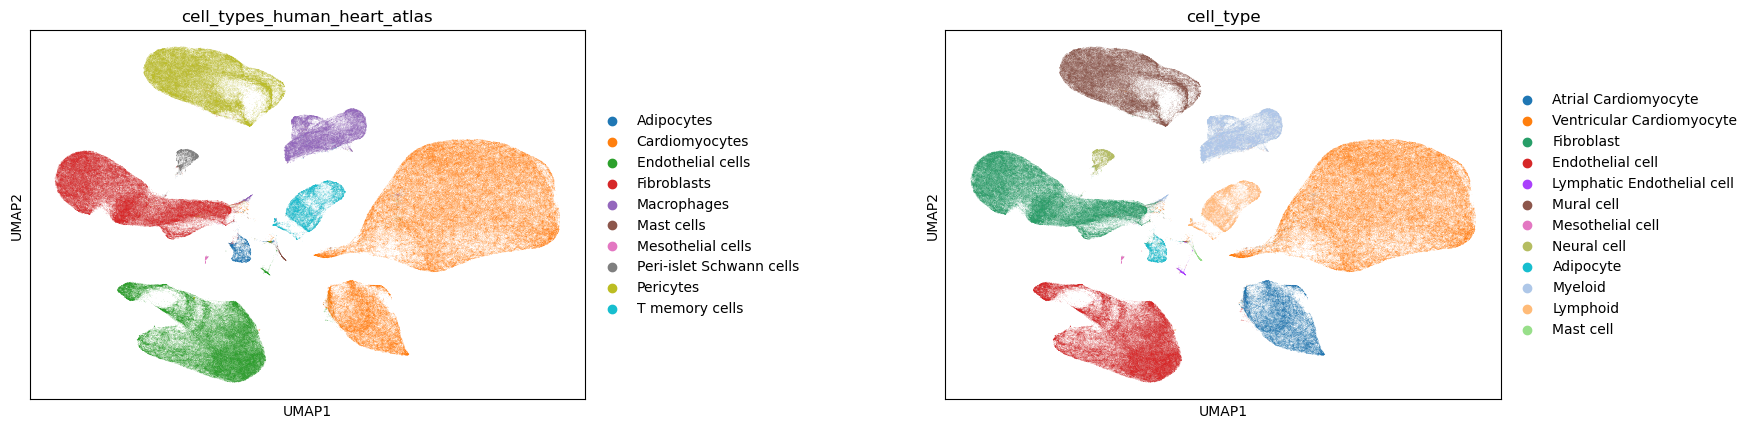

Tables of cell type annotation with clustering cell_type


,Cluster Endothelial cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cells,31327,143,194,15,0.775497,100
1,Endothelial cells (aorta),7033,49,89,14,0.053178,7
2,Monocytes,6659,36,103,16,0.023577,3
3,Platelets,6502,54,131,13,0.011996,2
4,Dendritic cells,6424,38,124,11,0.191469,25


,Cluster Mural cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Pericytes,5015,37,62,8,0.356730,100
1,Photoreceptor cells,3226,14,53,20,0.066646,19
2,Sertoli cells,3011,21,66,17,0.025241,7
3,Mesangial cells,2935,26,59,12,0.051107,14
4,Endothelial cells,2785,37,194,12,0.028366,8


,Cluster Myeloid,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Macrophages,7899,119,134,8,0.144069,48
1,Monocytes,6761,87,103,10,0.027659,9
2,Microglia,6574,59,72,10,0.265896,88
3,Platelets,4826,69,131,14,0.017406,6
4,Dendritic cells,4742,98,124,9,0.013286,4


,Cluster Fibroblast,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Fibroblasts,14456,134,176,10,0.623616,100
1,Adipocytes,5441,67,121,13,0.065981,11
2,Endothelial cells (aorta),5082,50,89,14,0.192641,31
3,Hematopoietic stem cells,4103,28,91,11,0.015355,2
4,Neuroendocrine cells,4040,14,26,9,0.008663,1


...

,Cluster Atrial Cardiomyocyte,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Cardiomyocytes,22026,79,107,16,0.709752,100
1,Podocytes,6393,43,98,16,0.041764,6
2,Retinal ganglion cells,6126,39,71,23,0.176787,25
3,Enteric neurons,5043,40,68,16,0.001190,0
4,Myocytes,5037,57,89,13,0.003971,1


,Cluster Mast cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Mast cells,1089,66,141,14,0.426079,100
1,T memory cells,625,18,55,11,0.110400,26
2,Purkinje neurons,556,23,61,10,0.034173,8
3,Macrophages,537,44,134,12,0.147114,35
4,Interneurons,458,83,224,13,0.048035,11


,Cluster Adipocyte,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Adipocytes,3037,83,121,14,0.389200,100
1,Hepatocytes,1855,109,151,18,0.103504,27
2,Immature neurons,1663,21,38,15,0.008419,2
3,Neurons,1649,114,205,16,0.000606,0
4,Podocytes,1648,57,98,16,0.031553,8


Output folder: ./annotation/ranked_markers/ranked/output/cell_type/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/exported_lists/ranked_markers 
Cluster folder: ./annotation/ranked_markers/ranked/clusters/cell_type/ 
Tissue: all
Created folder: ./annotation/ranked_markers/ranked/output/cell_type
Writing ranked cluster file sample.cluster_Endothelial cell (1/12)
Writing ranked cluster file sample.cluster_Mural cell (2/12)
Writing ranked cluster file sample.cluster_Myeloid (3/12)
Writing ranked cluster file sample.cluster_Fibroblast (4/12)
Writing ranked cluster file sample.cluster_Lymphoid (5/12)
Writing ranked cluster file sample.cluster_Neural cell (6/12)
Writing ranked cluster file sample.cluster_Ventricular Cardiomyocyte (7/12)
Writing ranked cluster file sample.cluster_Lymphatic Endothelial cell (8/12)
Writing ranked cluster file sample.cluster_Mesothelial cell (9/12)
Writing ranked cluster file sample.cluster_Atrial Cardiomyocyte (10/

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


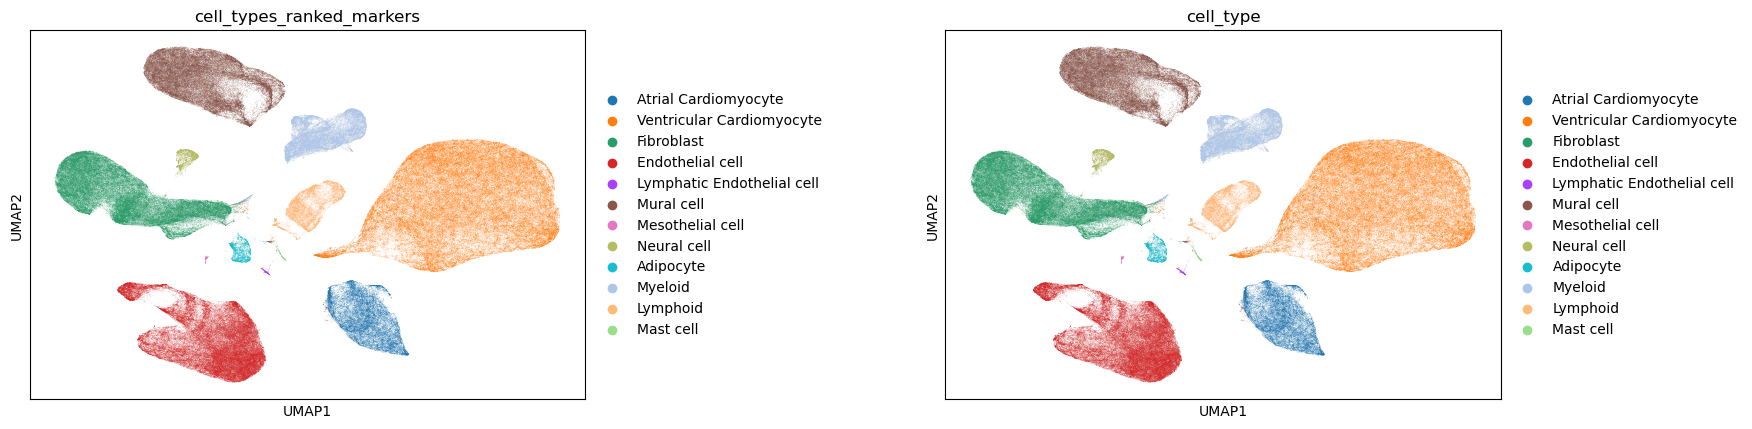

Tables of cell type annotation with clustering cell_type


,Cluster Endothelial cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cell,3639,100,100,1,0.649079,100
1,Lymphoid,1277,49,100,1,0.400157,62
2,Mesothelial cell,766,43,100,1,0.091384,14
3,Lymphatic Endothelial cell,696,55,100,1,0.606322,93
4,Myeloid,274,22,100,1,0.489051,75


,Cluster Mural cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Mural cell,2145,100,100,1,0.875991,100
1,Fibroblast,266,24,100,1,0.451128,51
2,Adipocyte,146,14,100,1,0.123288,14
3,Mast cell,128,18,100,1,0.062500,7
4,Mesothelial cell,120,24,100,1,0.000000,0


,Cluster Myeloid,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Myeloid,1903,100,100,1,0.657383,98
1,Lymphoid,652,89,100,1,0.164110,24
2,Mast cell,545,57,100,1,0.416514,62
3,Lymphatic Endothelial cell,318,36,100,1,0.018868,3
4,Mesothelial cell,312,37,100,1,0.163462,24


,Cluster Fibroblast,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Fibroblast,3168,100,100,1,0.760101,100
1,Neural cell,760,61,100,1,0.077632,10
2,Mesothelial cell,701,55,100,1,0.011412,2
3,Adipocyte,693,65,100,1,0.318903,42
4,Mural cell,472,46,100,1,0.216102,28


...

,Cluster Lymphatic Endothelial cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Lymphatic Endothelial cell,293,100,100,1,0.754266,100
1,Endothelial cell,72,66,100,1,0.250000,33
2,Mesothelial cell,54,48,100,1,0.092593,12
3,Lymphoid,49,51,100,1,0.040816,5
4,Myeloid,47,42,100,1,0.170213,23


,Cluster Mesothelial cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Mesothelial cell,267,100,100,1,0.767790,100
1,Endothelial cell,62,42,100,1,0.048387,6
2,Fibroblast,59,39,100,1,0.067797,9
3,Lymphoid,55,41,100,1,0.309091,40
4,Lymphatic Endothelial cell,38,43,100,1,0.157895,21


,Cluster Atrial Cardiomyocyte,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Atrial Cardiomyocyte,2919,100,100,1,0.225420,27
1,Ventricular Cardiomyocyte,2261,94,100,1,0.846970,100
2,Neural cell,346,40,100,1,0.231214,27
3,Adipocyte,266,38,100,1,0.071429,8
4,Lymphatic Endothelial cell,247,33,100,1,0.226721,27


,Cluster Mast cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Mast cell,404,100,100,1,0.784653,100
1,Myeloid,87,45,100,1,0.252874,32
2,Lymphoid,65,34,100,1,0.353846,45
3,Neural cell,42,28,100,1,0.119048,15
4,Lymphatic Endothelial cell,37,27,100,1,0.405405,52


,Cluster Adipocyte,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Adipocyte,973,100,100,1,0.736896,100
1,Fibroblast,256,74,100,1,0.375000,51
2,Mesothelial cell,160,54,100,1,0.062500,8
3,Neural cell,150,62,100,1,0.160000,22
4,Mural cell,126,29,100,1,0.150794,20


In [12]:
for marker_list in marker_lists:
    name = marker_list.split("/")[-1]
    annotation_dir = f"./annotation/{name}"
    
    # Annotate
    annot.annot_ct(adata, output_path=annotation_dir, db_path=marker_list,
                   cluster_column=f"{column}", rank_genes_column=rank_genes_column, 
                   ct_column=f"cell_types_{name}")
    
    # Plot annotation
    sc.pl.umap(adata, color=[f'cell_types_{name}', f'{column}'], wspace=0.5)

    # Show scores and alternate cell types of eacht cluster
    print(f"Tables of cell type annotation with clustering {column}")
    annot.show_tables(annotation_dir=annotation_dir, n=5, clustering_column=column, show_diff=True)

### Compare cell type annotations from Human Heart Atlas and MarkerRepo

In [13]:
compare_df = annot.compare_cell_types(adata, column, marker_lists)

In [14]:
compare_df.rename(columns={compare_df.columns[0]: "MarkerRepo Panglao",
                           compare_df.columns[1]: "MarkerRepo from AnnData"}, inplace=True)
compare_df.index.name = "Human Heart Atlas"
display(compare_df)

,MarkerRepo Panglao,MarkerRepo from AnnData
Human Heart Atlas,,
Atrial Cardiomyocyte,Cardiomyocytes,Atrial Cardiomyocyte
Ventricular Cardiomyocyte,Cardiomyocytes,Ventricular Cardiomyocyte
Fibroblast,Fibroblasts,Fibroblast
Endothelial cell,Endothelial cells,Endothelial cell
Lymphatic Endothelial cell,Endothelial cells,Lymphatic Endothelial cell
Mural cell,Pericytes,Mural cell
Mesothelial cell,Mesothelial cells,Mesothelial cell
Neural cell,Peri-islet Schwann cells,Neural cell
Adipocyte,Adipocytes,Adipocyte


### Show first two rows of internal annotation

In [15]:
internal_list = marker_lists[1]

In [16]:
marker_list = internal_list
name = marker_list.split("/")[-1]
annotation_dir = f"./annotation/{name}"

print(f"Tables of cell type annotation with clustering {column}")
annot.show_tables(annotation_dir=annotation_dir, n=2, clustering_column=column, show_diff=True)

Tables of cell type annotation with clustering cell_type


,Cluster Endothelial cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cell,3639,100,100,1,0.649079,100
1,Lymphoid,1277,49,100,1,0.400157,62


,Cluster Mural cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Mural cell,2145,100,100,1,0.875991,100
1,Fibroblast,266,24,100,1,0.451128,51


,Cluster Myeloid,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Myeloid,1903,100,100,1,0.657383,98
1,Lymphoid,652,89,100,1,0.164110,24


,Cluster Fibroblast,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Fibroblast,3168,100,100,1,0.760101,100
1,Neural cell,760,61,100,1,0.077632,10


...

,Cluster Lymphatic Endothelial cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Lymphatic Endothelial cell,293,100,100,1,0.754266,100
1,Endothelial cell,72,66,100,1,0.250000,33


,Cluster Mesothelial cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Mesothelial cell,267,100,100,1,0.767790,100
1,Endothelial cell,62,42,100,1,0.048387,6


,Cluster Atrial Cardiomyocyte,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Atrial Cardiomyocyte,2919,100,100,1,0.22542,27
1,Ventricular Cardiomyocyte,2261,94,100,1,0.84697,100


,Cluster Mast cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Mast cell,404,100,100,1,0.784653,100
1,Myeloid,87,45,100,1,0.252874,32


,Cluster Adipocyte,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Adipocyte,973,100,100,1,0.736896,100
1,Fibroblast,256,74,100,1,0.375000,51


### Show first two rows of external annotation

In [17]:
external_list = marker_lists[0]

In [18]:
marker_list = external_list
name = marker_list.split("/")[-1]
annotation_dir = f"./annotation/{name}"

print(f"Tables of cell type annotation with clustering {column}")
annot.show_tables(annotation_dir=annotation_dir, n=2, clustering_column=column, show_diff=True)

Tables of cell type annotation with clustering cell_type


,Cluster Endothelial cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cells,31327,143,194,15,0.775497,100
1,Endothelial cells (aorta),7033,49,89,14,0.053178,7


,Cluster Mural cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Pericytes,5015,37,62,8,0.356730,100
1,Photoreceptor cells,3226,14,53,20,0.066646,19


,Cluster Myeloid,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Macrophages,7899,119,134,8,0.144069,48
1,Monocytes,6761,87,103,10,0.027659,9


,Cluster Fibroblast,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Fibroblasts,14456,134,176,10,0.623616,100
1,Adipocytes,5441,67,121,13,0.065981,11


...

,Cluster Lymphatic Endothelial cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cells,1198,104,194,12,0.479132,100
1,Endothelial cells (aorta),624,48,89,16,0.126603,26


,Cluster Mesothelial cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Mesothelial cells,699,36,54,14,0.213162,78
1,Mast cells,550,59,141,17,0.138182,51


,Cluster Atrial Cardiomyocyte,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Cardiomyocytes,22026,79,107,16,0.709752,100
1,Podocytes,6393,43,98,16,0.041764,6


,Cluster Mast cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Mast cells,1089,66,141,14,0.426079,100
1,T memory cells,625,18,55,11,0.110400,26


,Cluster Adipocyte,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Adipocytes,3037,83,121,14,0.389200,100
1,Hepatocytes,1855,109,151,18,0.103504,27


### Save UMAP plot from Human Heart Atlas

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


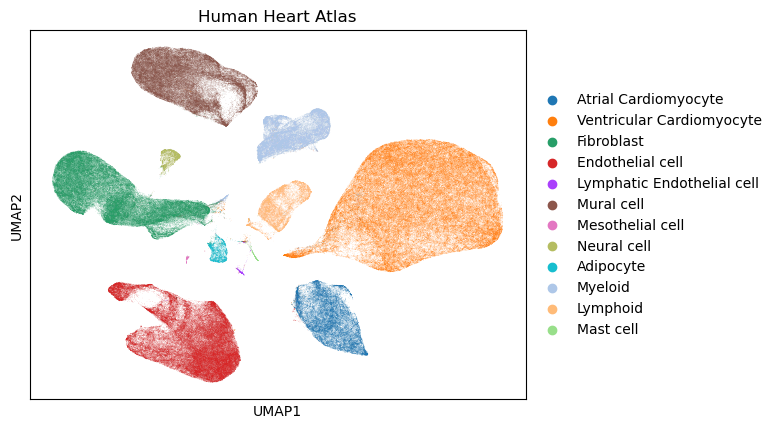

In [19]:
sc.pl.umap(adata, color=[f'cell_type'], title="Human Heart Atlas", save=f"_annotated_clusters.png")